# Concept Tutorial: Lifetimes

When pulsed excitation is used, 
the photon nanotimes contain significant information regarding fluoresence decays.

> **Caution**
>
> Fluoresence lifetimes can get very detailed.
> A complete description of fluoresence lifetimes is beyond this tutorial.
> Noteably anisotropy is not addressed.
> Make sure to consult sources like Principles of Fluoresence Spectroscopy by Joseph Lakowicz
> before claiming true lifetimes/anisotropy decays.

Photon nanotimes measure the delay between a sync signal aligined to the laser pulse and the detection of a photon.
When histograming these delay times, we usually obtain some variation on an exponential decay 
convolved with the instrument response function (IRF) of the setup.

The IRF is a product of the shape of the laser pulse and the accuracy and precision of the detectors and their electronics.

The decay may be single or multi exponential, the meaining of which requires knowledge of the system.
Different models attempt to use either discrete number of exponentials ie
$$I(t) = \sum{\alpha_{i}\exp{(-t/\tau_{i})}/\tau_{i}}$$
These work for systems where the environment is static (including for processes like FRET),
while others use distributions
$$I(t) = \int{\alpha(\tau)\exp{(-t/\tau)}/\tau d\tau}$$
Where $\alpha(\tau)$ is usually a model for a distance distribution, 
these are used more rarely when the system is more dynamic, 
for isntance invovling FRET where the fluorophores are attached to a dynamic polymer.

For this tutorial, we will load two example data sets,
the HP3 is a DNA hairpin, which was measured without polarization,
and another of the protein U2AF2, measured with polarization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import smfbursts as smf

# load HP3 data
raw_hp3 = smf.hdf5.load('data/HP3_TE300_SPC630.hdf5')
hp3 = smf.hdf5.regularize_dets(raw_hp3)
# make burst-search parameters for HP3 data
bg_hp3 = smf.ff.make_bg(hp3, func=smf.bg.exp_mlefit, 
                        auto_threshold=True, tail_min=5e-5)
bursts_hp3 = smf.ff.make_burst_search(bg=bg_hp3['bg'], m=10, F=6.0,
                                      streams=smf.PhSel('0ex_1em'))
gAll_hp3 = smf.make_geq_gate(bursts_hp3['NphActive_bg'], 60.0)
gDO_hp3 = gAll_hp3 & smf.make_geq_gate(bursts_hp3['S_bg'], 0.8)
gFret_hp3 = gAll_hp3 & smf.make_range_gate(bursts_hp3['S_bg'], 0.3, 0.8)


# load ptu files, note that this is customized for the
# particular configuration of these PTU, you will need to modify to be correct
# for your setup
def load_u2af2(file:str)->smf.PhotonData:
    raw = smf.lr.load_ptu(file)
    # set necessary parts of setup
    raw.setup['num_spectral_ch'] = 2
    raw.setup['num_polarization_ch'] = 2
    raw.setup['num_split_ch'] = 1
    raw.setup['excitation_wavelengths'] = np.array([532e-9, 642e-9])
    raw.setup['detection_wavelengths'] = np.array([585e-9, 698e-9])
    raw.setup['excitation_cw'] = np.array([False, False])
    raw.setup['excitation_alternated'] = np.array([False, False])
    raw.setup['detectors']['label'] = np.array(['ATTO 488', 'ATTO 643'])

    # remove the spectral_ploarization_split because it is there to identify 
    # detectors, but is not part of HDF5 spec
    meas_specs = raw.photon_data[0].meas_specs
    meas_specs['detectors_specs'].pop('spectral_polarization_split_chN', None)
    # Set detectors associataions
    spec1 = np.array([2,3], dtype=np.uint8)
    meas_specs['detectors_specs']['spectral_ch1'] = spec1
    spec2 = np.array([4,5], dtype=np.uint8)
    meas_specs['detectors_specs']['spectral_ch2'] = spec2
    pol1 = np.array([2,4], dtype=np.uint8)
    meas_specs['detectors_specs']['polarization_ch1'] = pol1
    pol2 = np.array([3,5], dtype=np.uint8)
    meas_specs['detectors_specs']['polarization_ch2'] = pol2
    ex1 = np.array([1850,3000])
    meas_specs['alex_excitation_period1'] = ex1
    ex2 = np.array([70,1500])
    meas_specs['alex_excitation_period2'] = ex2
    # render as processed file
    return smf.hdf5.regularize_dets(raw)

nums = (1, 4, 5, 6, 7, 8, 9, 10) # number of each mystery protein file
# load each file into PhotonData object in list
u2af2s = [load_u2af2(f'data/Lab8_U2AF2/mystery_protein_2_holo_ulm_{i}.ptu') for i in nums]
# Create grouped object
u2af2 = smf.PhotonDataList(u2af2s)

# make burst-search parameters for HP3 data
bg_u2af2 = smf.ff.make_bg(u2af2, func=smf.bg.exp_mlefit, 
                          auto_threshold=True, tail_min=5e-5)
bursts_u2af2 = smf.ff.make_burst_search(bg=bg_u2af2['bg'], m=10, F=6.0,
                                        streams=smf.PhSel('0ex_1em'))
gAll_u2af2 = smf.make_geq_gate(bursts_u2af2['NphActive_bg'], 60.0)
gDO_u2af2 = gAll_u2af2 & smf.make_geq_gate(bursts_u2af2['S_bg'], 0.8)
gFret_u2af2 = gAll_u2af2 & smf.make_range_gate(bursts_u2af2['S_bg'], 0.3, 0.8)

## The `nanohist` column

We can see the TCSPC histogram of any time range defined by a `smf.photondata.BasePhotonTable`
using the `nanohist` column.

The keys of `"nanohist"` are `(phsel:PhSel, full:bool=False)`
The `phsel` key defines over which photon streams to construct the TCSPC decay histogram,
while `full` determines over which range the photon selection is binned.
If `full=False` then the output bins are those of the entire TCSPC range.

In [2]:
# create example column objects, with full as True / False to compare
NhDD_hp3_f = smf.Column(bursts_hp3['bursts'], 'nanohist', 
                        (smf.PhSel('0ex0em'), False))

NhDD_hp3_t = smf.Column(bursts_hp3['bursts'], 'nanohist', 
                        (smf.PhSel('0ex0em'), True))

# get relavent columns
nhDD_f = hp3.get_column(NhDD_hp3_f)
nhDD_t = hp3.get_column(NhDD_hp3_t)
# compare shapes
print(f'full=False shape: {nhDD_f.shape}, full=True shape: {nhDD_t.shape}')

full=False shape: (127670, 1500), full=True shape: (127670, 4096)


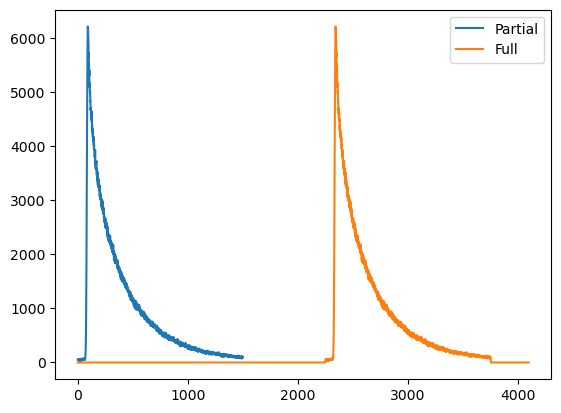

In [3]:
plt.plot(nhDD_f.sum(axis=0), label='Partial')
plt.plot(nhDD_t.sum(axis=0), label='Full')
plt.legend();

`nanohist` with multiple streams simply counts the number of photons in each TCSPC bin, separately for each burst.

We can see how the position of the position IRF changes due to speed of light delay between the two detectors.
(note that this can be addressed by setting `tcspc_offset` in the raw data under the `setup` dictionary)

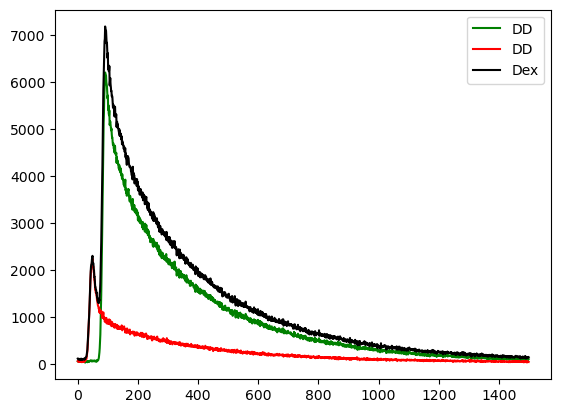

In [4]:
NhDA_hp3_f = smf.Column(bursts_hp3['bursts'], 'nanohist', 
                         (smf.PhSel('0ex1em'), False))
nhDA_f = hp3.get_column(NhDA_hp3_f)

NhDex_hp3_f = smf.Column(bursts_hp3['bursts'], 'nanohist', 
                         (smf.PhSel('0ex'), False))
nhDex_f = hp3.get_column(NhDex_hp3_f)

plt.plot(nhDD_f.sum(axis=0), label='DD', c='g')
plt.plot(nhDA_f.sum(axis=0), label='DD', c='r')
plt.plot(nhDex_f.sum(axis=0), label='Dex', c='k')
plt.legend();

`nanohist` can also take multiple excitation streams, at which point,
if `full=False` it will give the minimum available range, while the full tcspc range is reported if `full=True`

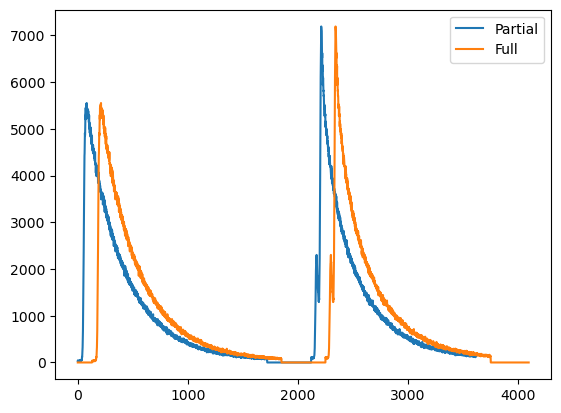

In [5]:
NhActive_hp3_f = smf.Column(bursts_hp3['bursts'], 'nanohist', 
                            (smf.PhSel('0ex_1ex1em'), False))
nhActive_hp3_f = hp3.get_column(NhActive_hp3_f).sum(axis=0)

NhActive_hp3_t = smf.Column(bursts_hp3['bursts'], 'nanohist', 
                            (smf.PhSel('0ex_1ex1em'), True))
nhActive_hp3_t = hp3.get_column(NhActive_hp3_t).sum(axis=0)

plt.plot(nhActive_hp3_f, label="Partial")
plt.plot(nhActive_hp3_t, label="Full")
plt.legend();

## Preliminaries: IRF

Knowledge of at least some parameters of the IRF are necessary for any lifetime analysis.
These are always specified for each detector index (single photon stream) separately,
as different excitation lasers will have different pulse shapes, and speed of light delays
will also affect each detector differently.

In the simple case we can assume the IRF is narrow enough to be approximated by a Kronecker delta, 
in which case all the information we need is the "center" of the IRF.
The `smf.PhotonData` object has a meta data field, `smf.PhotonData.irf_thresh` that lets us set
this center, for each photon stream. The value is set as a `smf.PhSel` key, with an integer value,
which is the photon nanotime to treat as this center.

In the more complex case we can go through the computationally more expensive
(though not that expensive) task of performing the convolution,
in which case we make an array of intensities for the IRF, which corresond to the
excitation range of the given photon stream.
We store these arrays in the `smf.PhotonData.irf` dictionary, whose keys are also `smf.PhSel` objects.
These must be arrays of the size of the exciation range

### Extracting IRF from measuremnt

The best way to obtain the IRF is from a separate measurement of either pure scattered light,
or from a highly quenched sample, such that the lifetime of the fluorophore can be considered
to be 0 relative to the size of the TCSPC bin.

smfBursts has the function `smf.as_irf`, which takes a `smf.PhotonData` object,
and assumes it is a measure of the IRF.
It returns a dictionary of the TCSPC histogram for each photon stream.

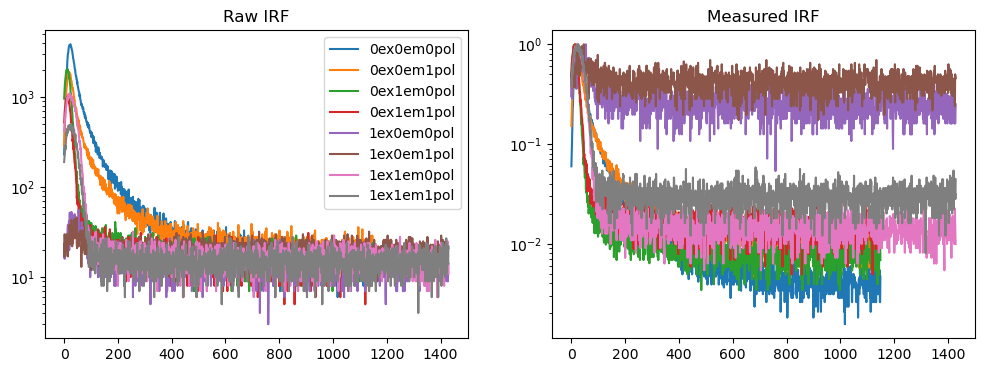

In [6]:
# load the data
u2af2_buffer = load_u2af2('data/Lab8_U2AF2/BSA+buffer.ptu')
# generate the TCSPC decay dictionary
u2af2_irf = smf.as_irf(u2af2_buffer)
# plot the recovered IRFs
fig, ax = plt.subplots(1,2, figsize=(12,4))
for sel, irf in u2af2_irf.items():
    ax[0].semilogy(irf, label=str(sel)) # raw IRF
    ax[1].semilogy(irf/irf.max()) # normalized IRF
ax[0].set_title("Raw IRF")
ax[1].set_title("Measured IRF")
ax[0].legend();

We note that the `1ex1em` keys both have very high background, as expected for anti-stokes streams.
So we will remove these, note however that this means that we will not be able to perform
lifetime related computations with these streams, but since they are anti-stokes, this is unlikely.

In [7]:
u2af2_irf.pop(smf.PhSel('1ex0em0pol'))
u2af2_irf.pop(smf.PhSel('1ex0em1pol'));

**Optional**

We usually want to "clean" up these *measured* IRFs, as they will include significant dark counts.
How this is done should be dependant on your knowledge of the system you are using.
But a good place to start is to estimate the average background counts in each TCSPC bin,
substract that, set all negative values to 0, and then set an additional intensity threshold below
which values are set to 0.

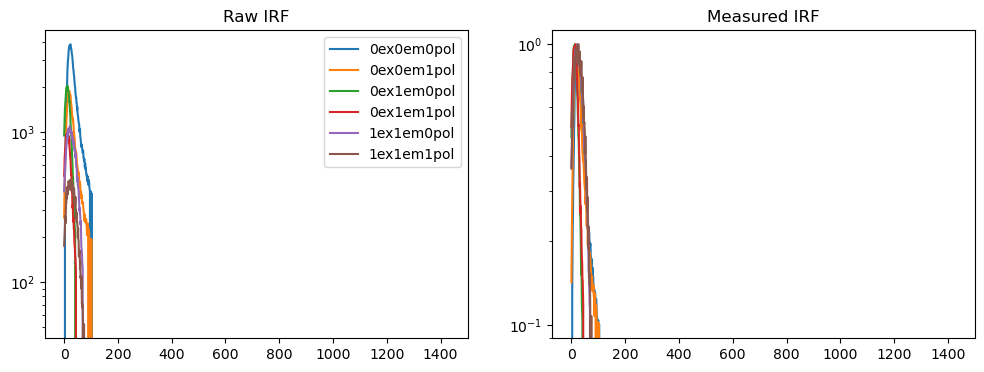

In [8]:
thresh = 0.1
bg_region = slice(-20, None)
# output for plots
fig, ax = plt.subplots(1,2, figsize=(12,4))
# remove background, optional
for sel, irf in u2af2_irf.items():
    irf -= irf[bg_region].mean(dtype=np.int64) # subtract background
    irf[irf < thresh * irf.max()] = 0.0 # set cutoff for IRF amplitude
    ax[0].semilogy(irf, label=str(sel))
    ax[1].semilogy(irf/irf.max(), label=str(sel))
# add labels
ax[0].set_title("Raw IRF")
ax[1].set_title("Measured IRF")
ax[0].legend();

Now we can set the IRF for each `smf.PhotonData` object.

> **Note**
>
> The `smf.PhotonData.irf` dictionary allows keys to be set only once.
> You can set multiple values at once using a dictonary,
> or individually as `data.irf[phsel] = irf_phsel`

Note that in this example, since `u2af2` is a `smf.PhotonDataList` object, we need to loop
over each data object it contains to set each of their irf dictionaries separetly.

In [9]:
for u2af2_sub in u2af2.datas:
    u2af2_sub.irf = u2af2_irf

### Setting IRF threshold

For setting IRF thresholds (for when we are using the point IRF approximation), we decide each individually.
The `smf.PhotonData.irf_thresh` is also seen as the point at which it is valid to use a tail fit for the decay.

> **Note**
>
> As we will see later, the methods for which the `smf.PhotonData.irf_thresh`
> are most useful, are genearlly better served with alternative methods that rely
> on the `smf.PhotonData.irf` instead.
> Thus these methods are generally discouraged, but sometimes they will be the best you can do.

A simple heuristic is the maximum of the TCSPC histogram of a given channel.

But here we will manually set each one based on the apparent decays:
Iterate below to find the best position for each stream of the threshold:

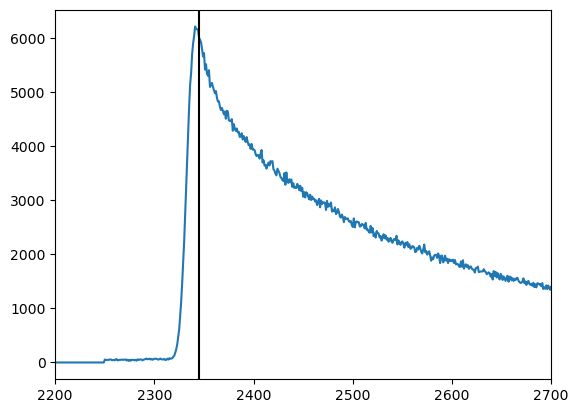

In [10]:
threshDD = 2345

# Note: if you have run this notebook sequentially, this is repeating
# earlier cells
# the repeat is for clarity regaring how we are extracting information

# make colum
NhDD_hp3_t = smf.Column(bursts_hp3['bursts'], 'nanohist',
                        (smf.PhSel('0ex0em'), True))
# get the histogram
nhDD_hp3_t = hp3.get_column(NhDD_hp3_t).sum(axis=0)

# plot TCSPC histogram
plt.plot(nhDD_hp3_t)
# add line to indicate position of threshold
plt.axvline(threshDD, c='k')
# play with these limits to get appropriate time range
plt.xlim([2200, 2700]);

We can now do the same for the other streams:

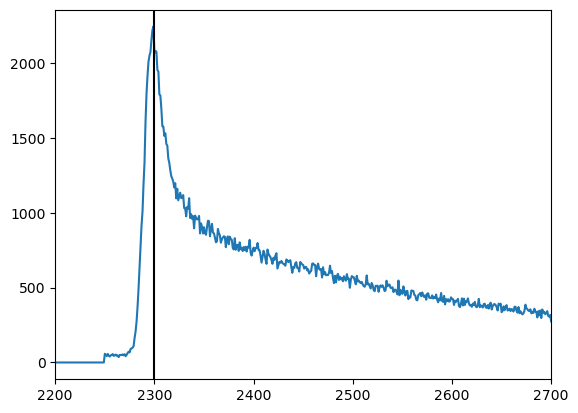

In [11]:
threshDA = 2300

# Note: if you have run this notebook sequentially, this is repeating
# earlier cells
# the repeat is for clarity regaring how we are extracting information

# make colum
NhDA_hp3_t = smf.Column(bursts_hp3['bursts'], 'nanohist',
                        (smf.PhSel('0ex1em'), True))
# get the histogram
nhDA_hp3_t = hp3.get_column(NhDA_hp3_t).sum(axis=0)

# plot TCSPC histogram
plt.plot(nhDA_hp3_t)
# add line to indicate position of threshold
plt.axvline(threshDA, c='k')
# play with these limits to get appropriate time range
plt.xlim([2200, 2700]);

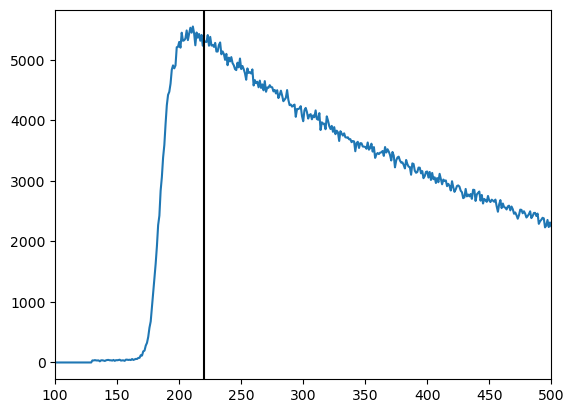

In [12]:
threshAA = 220

# Note: if you have run this notebook sequentially, this is repeating
# earlier cells
# the repeat is for clarity regaring how we are extracting information

# make colum
NhAA_hp3_t = smf.Column(bursts_hp3['bursts'], 'nanohist',
                        (smf.PhSel('1ex1em'), True))
# get the histogram
nhAA_hp3_t = hp3.get_column(NhAA_hp3_t).sum(axis=0)

# plot TCSPC histogram
plt.plot(nhAA_hp3_t)
# add line to indicate position of threshold
plt.axvline(threshAA, c='k')
# play with these limits to get appropriate time range
plt.xlim([100, 500]);

And now we can set each decay in the `smf.PhotonData.irf_thresh` dictionary:

In [13]:
hp3.irf_thresh[smf.PhSel('0ex0em')] = threshDD
hp3.irf_thresh[smf.PhSel('0ex1em')] = threshDA
hp3.irf_thresh[smf.PhSel('1ex1em')] = threshAA

## Mean decay lifetime columns

Probably the most commonly used lifetime-related column is the `nanomean_bg`, and it's simpler cousin `nanomean`.

`nanomean_bg` is a column of `smf.NphBG` tables, while `nanomean` is a column of `smf.photondata.BasePhotonTable` tables.
They both compute an estimator fo the amplitude weighted average lifetime of the burst.

For typical burst sizes (50-200 photons *per stream*) this is the only information that can reasonably determined.
Sufficient statistics cannot be acheived to recover values for multi-exponential decays.

Both `nanomean_bg` and `nanomean` have the same pair of keys:
`(phsel:smf.PhSel, irfstyle:{'thresh', 'mean', 'max'})`
For `nanomean_bg` the `phsel` is required, while `irfstyle` has a default of `"thresh"`.
For `nanomean` the `phsel` is required, while `irfstyle` has a default of `"thresh"`.

The first key is self-explanatory, the second is used to set the 0 point.
The options are:
- `"thresh"`: "time 0" of the decay is set by the value of `phsel` in `smf.PhotonData.irf_thresh`,
- `"mean"`: "time 0" of the decay is set by mean expectation value of the array of `phsel` in `smf.PhotonData.irf`
- `"max"`: "time 0" of the decay is set by index of the maximum value of the array of `phsel` in `smf.PhotonData.irf`

`nanomean` takes all photons *greater than or equal to* the time 0 in the stream, and computes their mean.
Since the mean of an exponential is the lifetime,
and of a multi-exponential the aplitude weigthed mean lifetime,
this is nominally the lifetime of the bursts.
**However** background photons are also present, 
which tend to bias this calculation towards longer lifetimes, 
and due to the IRF, those photons less than the time zero must be excluded.
In general, the "thresh" option is best for this column.

The solution: `nanomean_bg` which subtracts the expected contribution from background away.
This correction also enables photons before the time 0 to be included.
The calculation is as follows:
$$\tau = \frac{ \left(\displaystyle\sum_{i=1}^{N}{t_{i}}\right) - n_{bg}\bar{t_{bg}}}{N-n_{bg}}$$

where $N$ is the total number of photons, $t_{i}$ is the nanotime of the $i^{th}$ photon in the burst, 
with time 0 set by the choice of `irfstyle`.

**The `irfstyle` "mean" is the prefered (and default) option for `"nanomean_bg"` columns**.
The "thresh" style is available, but generally should be avoided, as setting the "time 0" later
than the center of the IRF results in underestimation fo the lifetime by this technique.

Below find examples of creating the different columns, and plotting their histograms relative to `E_bg`:

(-0.1, 1.1)

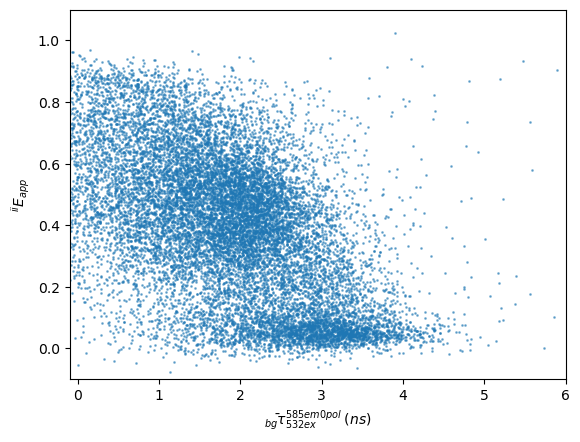

In [14]:
nmDD_u2af2 = smf.Column(bursts_u2af2['nphbg'], 'nanomean_bg',
                        (smf.PhSel('0ex0em0pol'), 'mean'))

smf.plot.scatter(u2af2, nmDD_u2af2, bursts_u2af2['E_bg'], gate=gFret_u2af2,
                 rescale=(-9, 0), s=1.0, alpha=0.5)
plt.xlim([-0.1, 6.0])
plt.ylim([-0.1, 1.1])

Note that the above column definition same as just supplying the `smf.PhSel` as a key:

In [15]:
nmDD_u2af2_1key = smf.Column(bursts_u2af2['nphbg'], 'nanomean_bg', 
                             smf.PhSel('0ex0em0pol'))

nmDD_u2af2_1key == nmDD_u2af2

True

Below is the definition using the max option (only slightly different values)

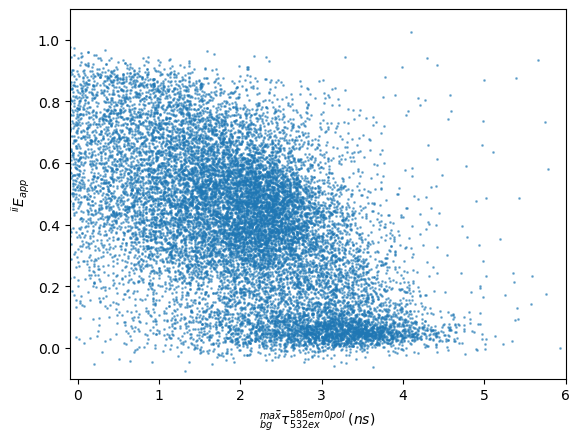

In [16]:
nmDD_u2af2_max = smf.Column(bursts_u2af2['nphbg'], 'nanomean_bg',
                            (smf.PhSel('0ex0em0pol'), 'max'))

smf.plot.scatter(u2af2, nmDD_u2af2_max, bursts_u2af2['E_bg'], gate=gFret_u2af2,
                 rescale=(-9, 0), s=1.0, alpha=0.5)
plt.xlim([-0.1, 6.0])
plt.ylim([-0.1, 1.1]);

The `"nanomean"` column works similarly, but note that it is not as accurate.
We use the HP3 because we have not set an IRF for this column:

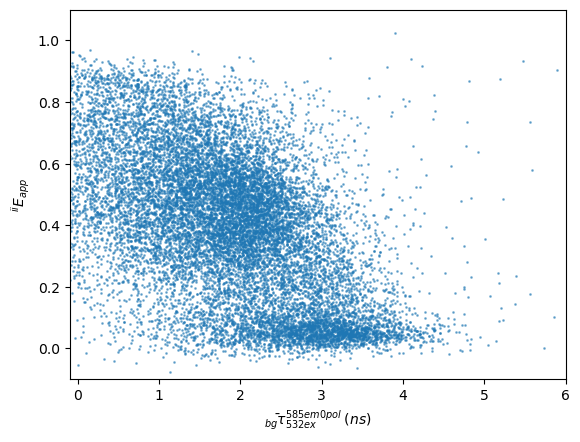

In [17]:
nmDD_hp3 = smf.Column(bursts_hp3['bursts'], 'nanomean',
                        (smf.PhSel('0ex0em'), 'thresh'))

smf.plot.scatter(u2af2, nmDD_u2af2, bursts_u2af2['E_bg'], gate=gFret_u2af2,
                 rescale=(-9, 0), s=1.0, alpha=0.5)
plt.xlim([-0.1, 6.0])
plt.ylim([-0.1, 1.1]);

We can also see how the default value of "thresh" is used for the `irfstyle`:

In [18]:
nmDD_hp3_1key = smf.Column(bursts_hp3['bursts'], 'nanomean', 
                           smf.PhSel('0ex0em'))

nmDD_hp3 == nmDD_hp3_1key

True

## Fitting Bursts summed decays:

smfBursts is primarily focused on computing values of bursts,
however, it does provide some convenience functions for fitting decays of time ranges.

This is done with the `smf.lt.fit_fldecay` function.
The basic signature is `smf.lt.fit_fldecay(data, phsel, gate=None, ndec=1)`
This call will fit the decay of the selection `phsel` (optionally filtered by `gate`) 
to a `ndec` exponential decay.
In the above form, initial values are set by an initial estimation, and it is assumed that
the IRF is also being fit as a Gaussian.

It should be noted that this function passes `**kwargs` to `scipy.optimize.minimize`

The output is a dictionary, with the following keys:
- "taus" the lifetimes (in seconds) of each decay
- "amps" the amplitudes of each decay (note that all decays are normalized by lifetime)
- "bg" the fraction of signal originating from background
- "result" the result object from `scipy.optimize.minimize`
- "irf_func" the function usd to compute the simulated IRF
- "irf_params" (only sometimes) the parameters, typically the center and width of a gaussian (see later for variations)

In [19]:
fitDO_hp3 = smf.lt.fit_fldecay(hp3, smf.PhSel('0ex0em'), gate=gDO_hp3,
                               method='Nelder-Mead')

fitDO_hp3['taus']

array([3.84801232e-09])

We can plot the result by using either `smf.lt.fldecay_firf_bg_norm` or `smf.lt.fldecay_bg_norm`, 
depending on whether the IRF is fit or provided.
Both of these functions have the same arguments as the keys of the output of `smf.lt.fit_fldecay`,
while requireing a `t` argument.

> **Note**
> The output of `smf.lt.fit_fldecay` has some keys that are not used by
> `smf.lt.fldecay_firf_bg_norm` and/or `smf.lt.fldecay_bg_norm`, but these functions
> have \*\*kwargs so additional keys are ignored.

We can also see the use of the `smf.PhotonData.get_tcspc_decay` method,
which takes a `smf.PhSel` and optionally a `smf.GateGroup` or `smf.Param`
to define the subset of time ranges to build the TCSPC histogram.
The method outputs a 2-tuple of the times of the TCSPC bins, and the TCSPC histogram.
When used with a gate, it is equivalent to the pattern we saw before of
`nanohist = data.get_column(nanohist_col).sum(axis=0)`.

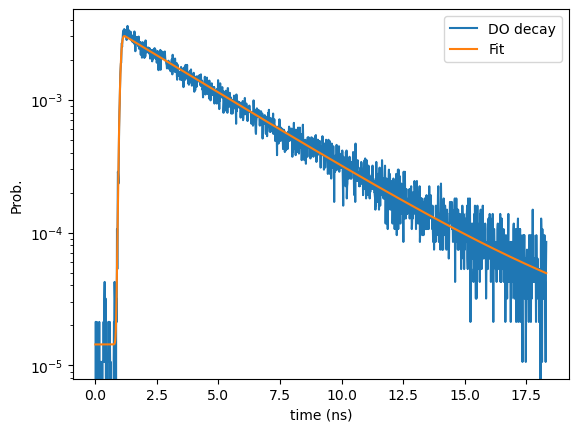

In [20]:
t, dec = hp3.get_tcspc_decay(smf.PhSel('0ex0em'), gDO_hp3)
plt.semilogy(1e9*t, dec/dec.sum(), label='DO decay')
plt.semilogy(1e9*t, smf.lt.fldecay_firf_bg_norm(t=t, **fitDO_hp3), 
             label='Fit')
plt.xlabel('time (ns)')
plt.ylabel('Prob.')
plt.legend();

### IRF parameters in fit

In the above case, we did not have a measured IRF, so the fit function
used a Gaussian.
We can recover that simulated IRF from the dictionary, as the function used
to create it is recorded in the output, and so are its parameters.

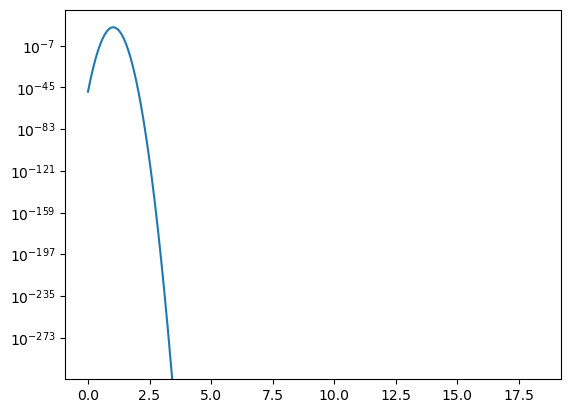

In [21]:
irf_rec_hp3 = fitDO_hp3['irf_func'](t, *fitDO_hp3['irf_params'])
plt.semilogy(t*1e9, irf_rec_hp3)

We can plot all elements together now,

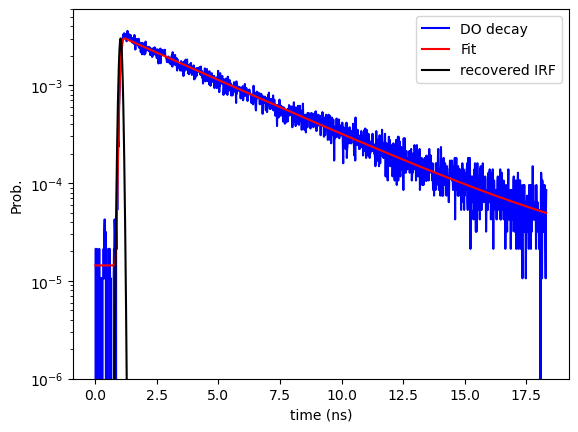

In [22]:
plt.semilogy(1e9*t, dec/dec.sum(), label='DO decay', c='b')

sim_dec = smf.lt.fldecay_firf_bg_norm(t=t,**fitDO_hp3)

plt.semilogy(1e9*t, sim_dec,
             label='Fit', c='r')
irf_renorm = irf_rec_hp3/irf_rec_hp3.max()*sim_dec.max() #match height of decay
plt.semilogy(1e9*t, irf_renorm, label='recovered IRF', c='k')

plt.xlabel('time (ns)')
plt.ylabel('Prob.')
plt.ylim([1e-6, 6.0e-3])
plt.legend()

We can use this as the IRF in the `smf.PhotonData.irf` dictionary (so long as there is not better option)

In [23]:
hp3.irf[smf.PhSel('0ex0em')] = irf_rec_hp3

### `smf.lt.fit_decay` keyword arguments

By setting the keyword argument `ndec=2` we can fit a bi-exponential decay.
The `irf` keyword argument can be set to `True` if you want to use the experimental IRF stored in `smf.PhotonData.irf`,
or you can supply `irf` as an array of the IRF (this could for instance be used to test IRFs before setting one of them as `smf.PhotonData.irf`)

We can also set `tau_init`, 

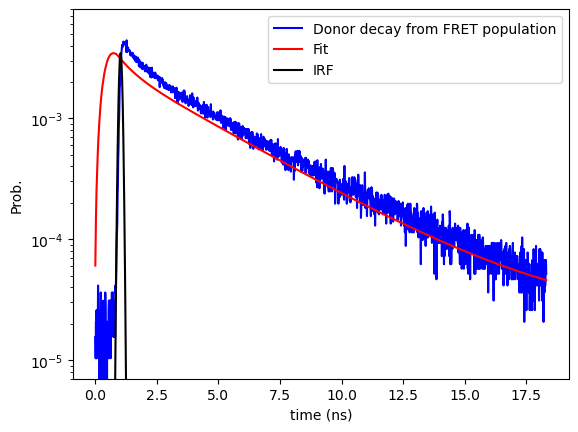

In [24]:
fitFret_hp3 = smf.lt.fit_fldecay(hp3, smf.PhSel('0ex0em'), 
                                   gate=gFret_hp3, irf=True, ndec=2,
                                   method='Nelder-Mead')

t, dec = hp3.get_tcspc_decay(smf.PhSel('0ex0em'), gFret_hp3)
dec_norm = dec/dec.sum()
plt.semilogy(1e9*t, dec_norm, label='Donor decay from FRET population', c='b')

fit_dec = smf.lt.fldecay_bg_norm(t=t, irf=irf, **fitFret_hp3)
plt.semilogy(1e9*t, fit_dec, label='Fit', c='r')
irf = hp3.irf[smf.PhSel('0ex0em')]
irf_norm = irf/irf.max()*fit_dec.max()
plt.semilogy(1e9*t, irf_norm, c='k', label="IRF")


plt.xlabel('time (ns)')
plt.ylabel('Prob.')
plt.ylim([7.0e-6, 8.0e-3])
plt.legend();

## Phasor plots

The lifetime module also includes as `smf.photondata.ChildPhotonTable` which
handles phasor analysis of burst nanotimes.
This can indicate the presence of multi-eponential decays within a burst.
However, take all values with a grain of salt because of the small statistics available.

The basic idea of phasor is to take the phasor transform of the TCSPC decay histogram 
(descibed in [Digman et. al. 2008](https://doi.org/10.1529/biophysj.107.120154)):

$$g = \displaystyle\int_{t_{start}}^{t_{end}}{I(t)\cos(\omega t)dt} \equiv \sum_{i=1}^{N}{t_{i}\cos(\omega t_{i})}$$

$$s = \displaystyle\int_{t_{start}}^{t_{end}}{I(t)\sin(\omega t)dt} \equiv \sum_{i=1}^{N}{t_{i}\sin(\omega t_{i})}$$

The `smf.Phasor` table requies a single parent: `"base"`, which can be any `smf.photondata.BasePhotonTable`.


It has 3 parameters, all of which have defaults:
- "omega" : the rotational frequency of the phasor, this has 2 automatic options:
  0.0 and -1.0, if 0.0 the phasor is set to 0.0, omega is the angular frequency of the laser repetition rate,
  if omega is -1.0, then omega is the angular frequency of the excitation window of the given stream.
  This can be supplied as an array, 1 for each photon stream.
- "start" has the same options as the `nanomean` and `nanomean_bg` second key, setting the 0 time, defaults to "mean"
- "exclude": whether or not to set $t_{start}$ as 0 (True), or at beginning of excitation period (False)

It should be noted that you can alternatively specify "period" when creating a phasor,
and the period (in seconds) will be converted to the angular frequency as $\omega = 2\pi / T$ where $T$ is the period.

In [25]:
phasor_hp3 = smf.Param(smf.Phasor, base=bursts_hp3['bursts'], omega=0.0, 
                       start='thresh')
print(phasor_hp3.description)

Table: Phasor
Params:
  omega: [0. 0.]
  start: thresh
  exclude: True
Parents:
  base:  Table: Bursts
    Params:
      func: smfbursts.bursttables.burstsearch_mwindowF_bg
      stream: 0ex_1em
      m: 10
      F: 6.0
      c: -1.0
      fuse: 0.0
    Parents:
      bg:  Table: BG
        Params:
          compute_stream: single_all
          func: smfbursts.backgroundtables.exp_mlefit
          tail_min: [5.e-05 5.e-05 5.e-05 5.e-05 5.e-05]
          auto_threshold: True
          F_bg: 2.0
        Parents:
          base:  Table: Periods
            Params:
              period: 60.0
              start_at: time_min
              stop_at: over
              detdef: DetDef2ex2em


The columns for the $g$ and $s$ parameters are `"phasor_g"` and `"phasor_s"` respectively.
They each have 1 key: the photon stream for which to assess the phasor.

In [26]:
phsG_hp3 = smf.Column(phasor_hp3, 'phasor_g', smf.PhSel('0ex0em'))
print(phsG_hp3.description)

Column: Phasor, phasor_g, 0ex0em
  Params:
    omega: [0. 0.]
    start: thresh
    exclude: True
  Parents:
    base:  Table: Bursts
      Params:
        func: smfbursts.bursttables.burstsearch_mwindowF_bg
        stream: 0ex_1em
        m: 10
        F: 6.0
        c: -1.0
        fuse: 0.0
      Parents:
        bg:  Table: BG
          Params:
            compute_stream: single_all
            func: smfbursts.backgroundtables.exp_mlefit
            tail_min: [5.e-05 5.e-05 5.e-05 5.e-05 5.e-05]
            auto_threshold: True
            F_bg: 2.0
          Parents:
            base:  Table: Periods
              Params:
                period: 60.0
                start_at: time_min
                stop_at: over
                detdef: DetDef2ex2em


In [27]:
phsS_hp3 = smf.Column(phasor_hp3, 'phasor_s', smf.PhSel('0ex0em'))
print(phsS_hp3.description)

Column: Phasor, phasor_s, 0ex0em
  Params:
    omega: [0. 0.]
    start: thresh
    exclude: True
  Parents:
    base:  Table: Bursts
      Params:
        func: smfbursts.bursttables.burstsearch_mwindowF_bg
        stream: 0ex_1em
        m: 10
        F: 6.0
        c: -1.0
        fuse: 0.0
      Parents:
        bg:  Table: BG
          Params:
            compute_stream: single_all
            func: smfbursts.backgroundtables.exp_mlefit
            tail_min: [5.e-05 5.e-05 5.e-05 5.e-05 5.e-05]
            auto_threshold: True
            F_bg: 2.0
          Parents:
            base:  Table: Periods
              Params:
                period: 60.0
                start_at: time_min
                stop_at: over
                detdef: DetDef2ex2em


### Phasor behavior

As seen in [Digman et. al. 2008](https://doi.org/10.1529/biophysj.107.120154),
we can expect for a single expoential decay

$$g(\tau) = \frac{1}{1+(\omega\tau)^{2}}$$

$$s(\tau) = \frac{\omega\tau}{1+(\omega\tau)^{2}}$$

This means that if decays are a single exponential, then they will lie along the
semicircle
$$s = \sqrt{g(1-g)}$$

Values less than this are indicative of multi-expoenential decays, and the closer to 0 in $g$ the longer the lifetime.

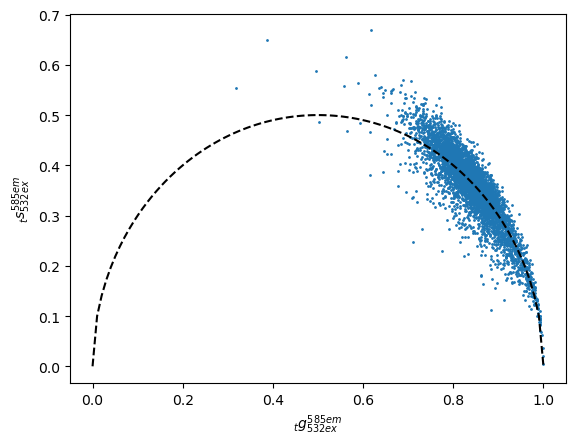

In [28]:
smf.plot.scatter(hp3, phsG_hp3, phsS_hp3, gate=gFret_hp3, s=1.0)

g = np.linspace(1e-9,1,100)
s = np.sqrt(g*(1-g))
plt.plot(g, s, ls='--', c='k')

#### Recovinger $\omega$

Because $\omega$ can be set automatically, the `smf.Phasor.omega_vals` parammethod exists.
It requires a photon selection, and if the value of $\omega$ is automatically set, 

In [29]:
phasor_hp3.omega_vals(smf.PhSel('0ex0em'), hp3)

array([1.25579394e+08])

This concludes the tutorial.